In [40]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

In [42]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [43]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = np.nan                   # Magnification rate from input to objective
w_0 = np.nan                 # mm
alpha = np.arcsin(num_apt / n)

#10 microns
L_ffp = 0.01
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)



In [44]:
f = np.load("images/usaf_resolution.npy") * 1
rng = np.random.default_rng(15)
true_aberration = generate_johnson_aberration(523/523, alpha, rng)

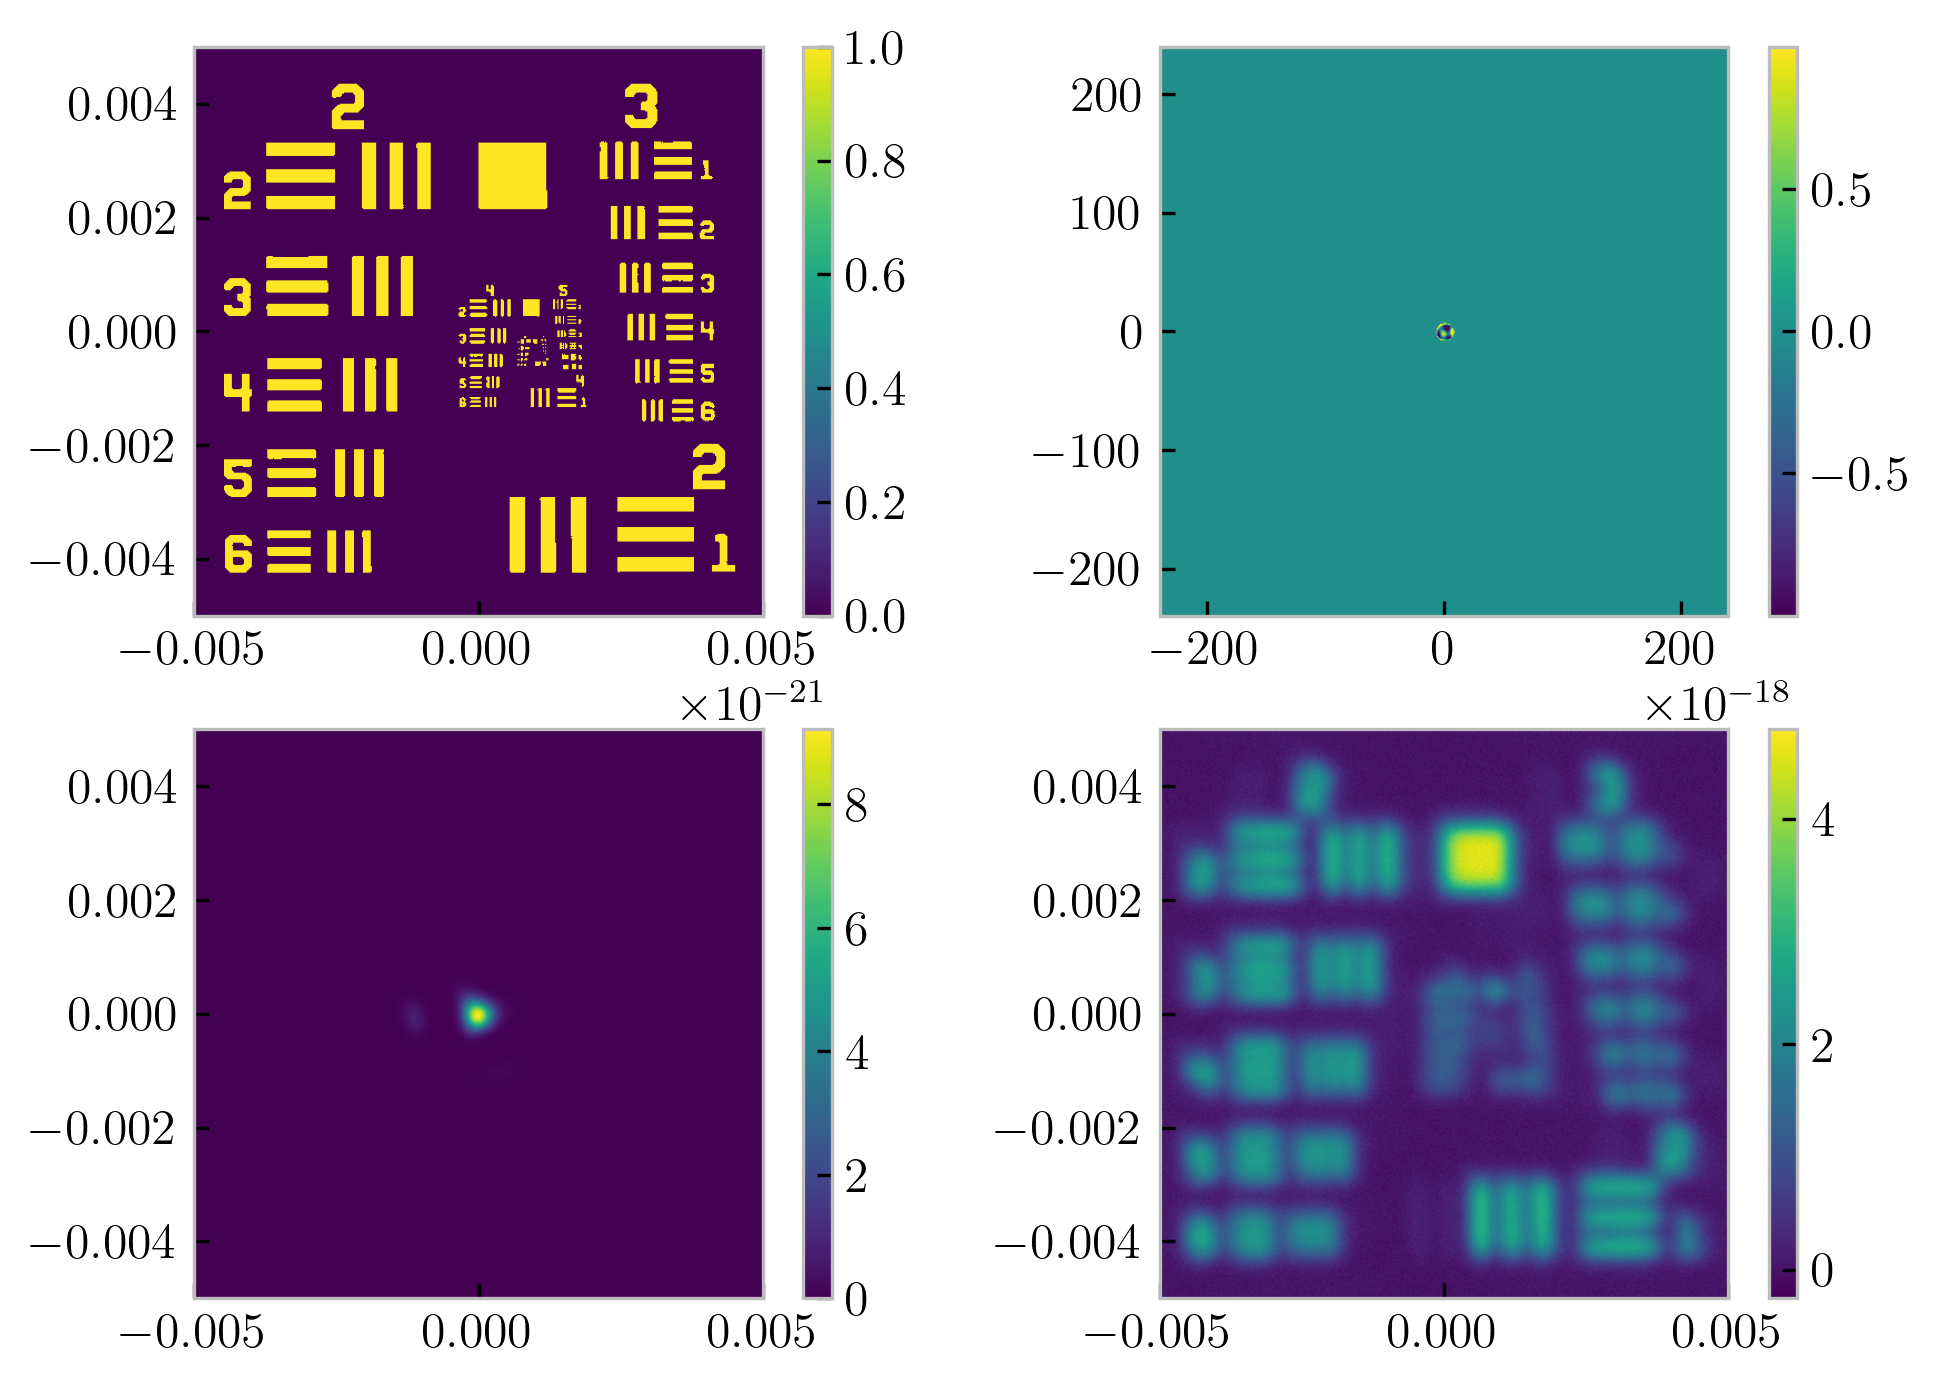

In [45]:
SNR = 30

H = forward_H(microscope, true_aberration)
PSF = forward_PSF(microscope, true_aberration)
#plot_intensity(x, y, PSF, normalize = False)
d = forward_image(microscope, f, true_aberration)
d = add_gaussian_noise(d, SNR, rng)
#plot_intensity(x, y, d, normalize = False)

fig, axs = plt.subplots(2, 2)
axs = axs.flatten()

im0 = axs[0].imshow(f,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im1 = axs[1].imshow(np.imag(H),
                    extent=[x_bfp[0], x_bfp[-1], y_bfp[0], y_bfp[-1]],)

im2 = axs[2].imshow(PSF,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im3= axs[3].imshow(d,
                   extent=[x[0], x[-1], y[0], y[-1]],)

for ax in axs:
    ax.grid(False)
    #ax.set_xticks([])
    #ax.set_yticks([])



fig.colorbar(im0, ax = axs[0])
fig.colorbar(im1, ax = axs[1])
fig.colorbar(im2, ax = axs[2])
fig.colorbar(im3, ax = axs[3])

In [63]:
bias_modes = [[-2,2], [0,2], [2,2],
[0, 4], [-4,4], [4,4]]
bias_strength = 500/523
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]
d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
d_stack = [add_gaussian_noise(d, SNR, rng) for d in d_stack]

In [64]:
params = {
    "gamma": 1e-10,
    "J_tol": 0.001,
    "max_step": 0.1
}

modes_corrected = get_johnson_modes()

c_guess, F_guess  = loop_optimize(n_loops = 100,
                                            microscope = microscope,
                                            d_stack = d_stack,
                                            a_stack = a_stack,
                                            modes_corrected = modes_corrected,
                                            params = params,
                                            debug = True,
                                            log = False)

  0%|          | 0/100 [00:00<?, ?it/s]

Loop 1: J = 9.107452183608767e-26
Corrercted Zernike Mode: [[-2  2]
 [ 0  2]
 [ 2  2]
 [-3  3]
 [-1  3]
 [ 1  3]
 [ 3  3]
 [-4  4]
 [-2  4]
 [ 0  4]
 [ 2  4]
 [ 4  4]
 [-5  5]
 [-3  5]
 [-1  5]
 [ 1  5]
 [ 3  5]]
Estimated Zernike Coefficients: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
	 Estimated object in 0.019 seconds
	 Estimated gradient in 0.123 seconds


  0%|          | 0/100 [00:46<?, ?it/s]


KeyboardInterrupt: 

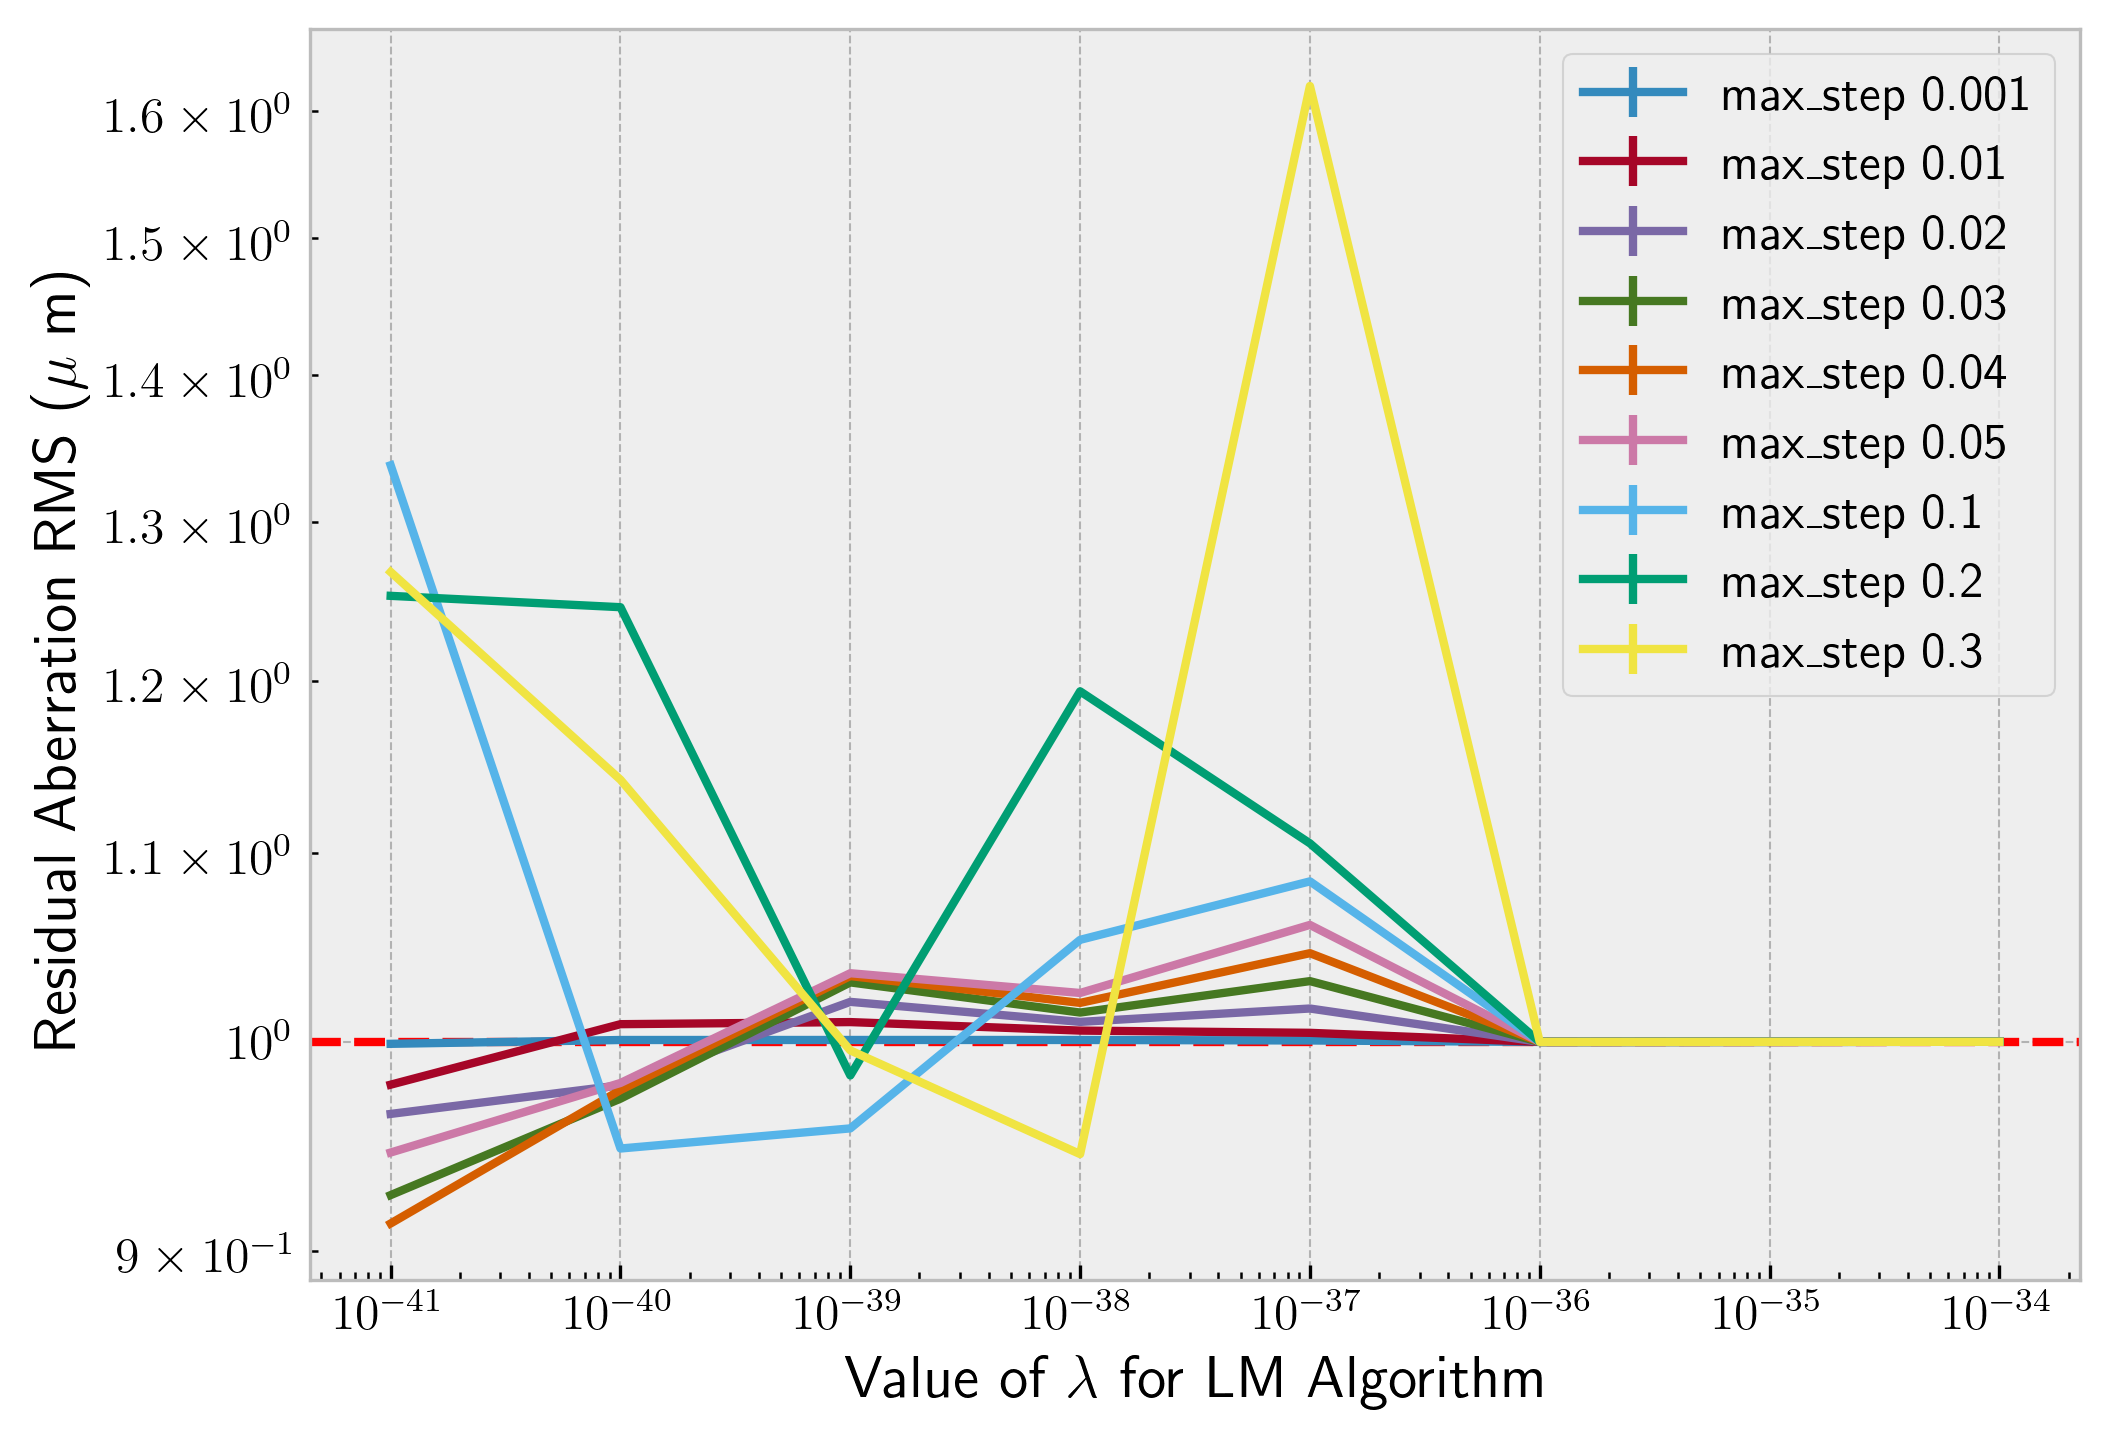

In [75]:
max_step_vals = [0.001, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3]
l_m_vals = [1e-41, 1e-40, 1e-39, 1e-38, 1e-37, 1e-36, 1e-35, 1e-34]
num_samples = 1

c_true = np.load("results/maxstep_3p_converged.npy")
c_converged = np.load("results/maxstep_3p_true.npy")
modes = get_johnson_modes()

fig, ax = plt.subplots(dpi=300)

#colors = ["blue", "green", "orange", "red"]
#markers = ["^", "v", "d", "o"]
for j, max_step in enumerate(max_step_vals):
    rms_list = np.zeros((len(l_m_vals), num_samples))

    for k, l_m in enumerate(l_m_vals):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms
        #* 523 nm / wv * 1 mum /1000 nm

    ax.errorbar(
        l_m_vals,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"max_step {max_step}"
    )

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Value of $\lambda$ for LM Algorithm")
ax.set_ylabel("Residual Aberration RMS ($\mu$ m)")
#ax.set_ylim(0, 0.3)
#x = np.arange(0, 0.25, 0.01)
ax.axhline(1, color = "red", ls = "dashed")
plt.savefig("figures/3p_maxstep")